In [1]:
import pandas as pd
import numpy as np

In [2]:
df_studentInfo = pd.read_csv("/content/drive/MyDrive/Dataset/studentInfo.csv")
df_studentVle = pd.read_csv("/content/drive/MyDrive/Dataset/studentVle.csv")
df_studentAssessment = pd.read_csv("/content/drive/MyDrive/Dataset/studentAssessment.csv")

In [3]:
print(df_studentInfo.shape)
df_studentInfo.head(5)

(32593, 12)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [4]:
print(df_studentVle.shape)
df_studentVle.head(5)

(10655280, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [5]:
print(df_studentAssessment.shape)
df_studentAssessment.head(5)

(173912, 5)


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [6]:
result = df_studentInfo['final_result'].unique()
result

array(['Pass', 'Withdrawn', 'Fail', 'Distinction'], dtype=object)

In [7]:
df_studentInfo['final_result'].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


In [8]:
df_studentInfo.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [9]:
df_studentVle['id_student'].nunique()

26074

studentInfo có 32593 sinh viên, studentVle có 26074 sinh viên unique.
Tức là có khoảng 6500 sinh viên có trong studentInfo nhưng không có bất kỳ click nào trong hệ thống VLE. Khả năng cao 6500 sinh viên đó đã hủy môn hoặc thôi học.

In [10]:
withdraw_students = df_studentInfo[~df_studentInfo['id_student'].isin(df_studentVle['id_student'])]
withdraw_students['final_result'].value_counts()

,count
final_result,
Withdrawn,2516
Fail,333
Pass,3


2516 sinh viên bỏ học nên không click cái nào. 333 Fail không click — đúng, OULAD là khóa học online của Open University UK, nhưng vẫn có thể có assessment offline. Hoặc đơn giản là họ đăng ký rồi... không làm gì hết cho đến khi fail.
3 Pass không click — khả năng cao là data quality issue — missing data trong studentVle, không phải họ thực sự không click gì.

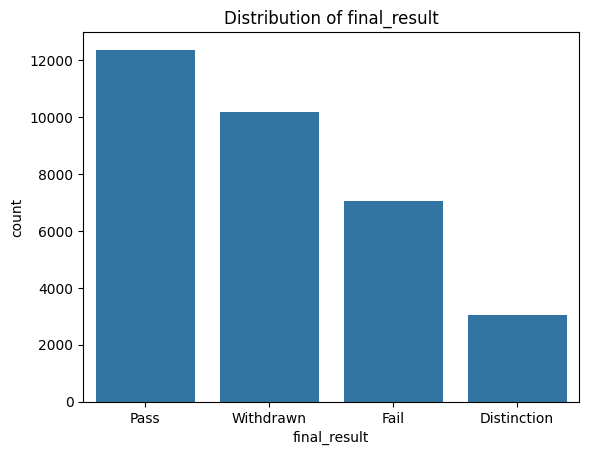

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_studentInfo, x = df_studentInfo['final_result'])
plt.title('Distribution of final_result')
plt.show()

Đạt + Xuất sắc = 12361 + 3024 = 15385
Rút lui + Trượt = 10156 + 7052 = 17208
Tổng = 32593

15385 / 32593 ≈ 47% thành công, 53% thất bại.

hơn nửa sinh viên không hoàn thành khóa học. Withdrawn chiếm tỉ lệ rất lớn — đây không phải dataset "bình thường", đây là dataset về dropout.

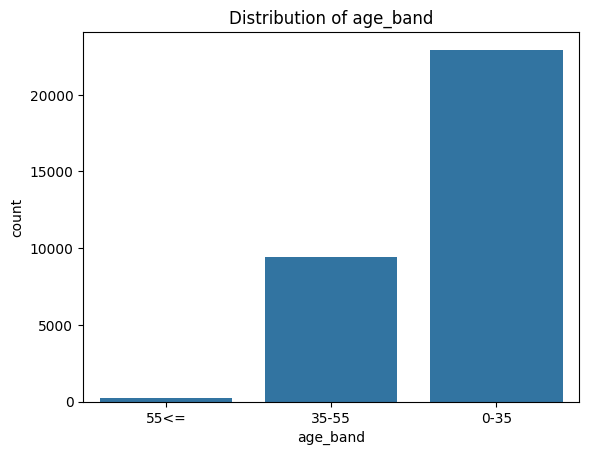

In [12]:
sns.countplot(data=df_studentInfo, x=df_studentInfo['age_band'])
plt.title('Distribution of age_band')
plt.show()

age_band có 3 nhóm — nhóm 0-35 chiếm đa số. Open University UK là trường học từ xa (distance learning), chủ yếu cho người đi làm. Vậy tại sao nhóm trẻ nhất lại đông nhất thay vì 35-55?

Open University UK nhận cả sinh viên không có bằng A-level — tức là người trẻ chưa vào được đại học truyền thống cũng học ở đây. Đó là tệp lớn nhất. Không phải vì người già không học, mà vì pool người trẻ to hơn nhiều.

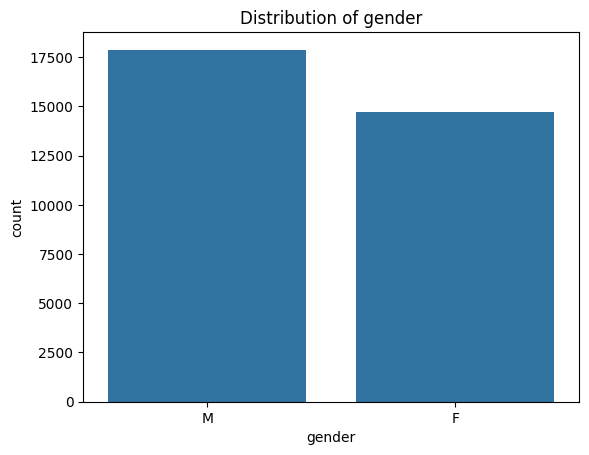

In [13]:
sns.countplot(data=df_studentInfo, x=df_studentInfo['gender'])
plt.title('Distribution of gender')
plt.show()

gender khá cân bằng nhưng nam nhiều hơn nữ một chút.

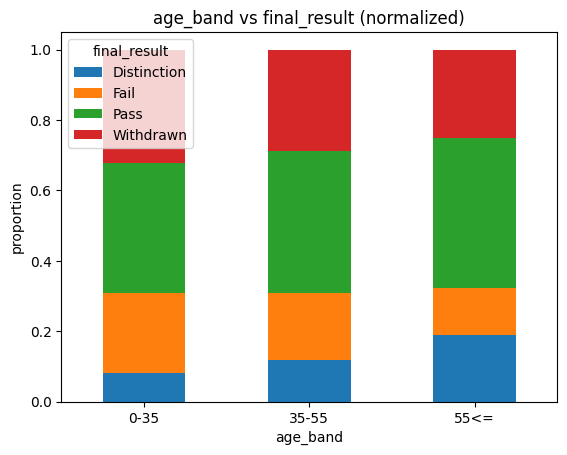

In [14]:
ct = pd.crosstab(df_studentInfo['age_band'],
                 df_studentInfo['final_result'],
                 normalize='index')
ct.plot(kind='bar', stacked=True)
plt.title('age_band vs final_result (normalized)')
plt.ylabel('proportion')
plt.xticks(rotation=0)
plt.show()

Nhìn vào biểu đồ ta thấy
1. Nhóm có tỷ lệ withdraw cao nhất là từ 0-35
2. Nhóm có tỷ lệ Distinction cao nhất là 55+
3. age_band có vẻ là một feature hữu ích do có vẻ là chúng có sự liên quan khi càng giàng thì có vẻ càng chăm học

In [15]:
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_studentInfo['age_band'], df_studentInfo['final_result'])
chi2, p, dof, expected = chi2_contingency(ct)

print(f'Chi2: {chi2:.2f}')
print(f'P-value: {p: .6f}')

Chi2: 222.65
P-value:  0.000000


P-value = 0.000000 nghĩa là gần như 0 — nhỏ hơn 0.05 rất nhiều.

Kết luận: mối quan hệ giữa age_band và final_result không phải ngẫu nhiên. Có ý nghĩa thống kê.

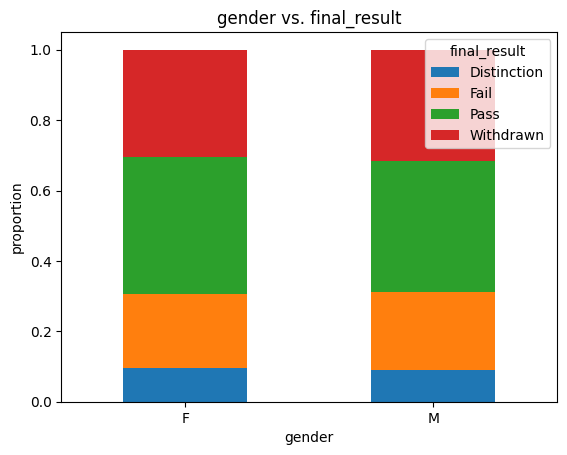

In [16]:
ct = pd.crosstab(df_studentInfo['gender'], df_studentInfo['final_result'], normalize='index')
ct.plot(kind='bar', stacked=True)
plt.title("gender vs. final_result")
plt.ylabel("proportion")
plt.xticks(rotation=0)
plt.show()

In [17]:
ct = pd.crosstab(df_studentInfo['gender'], df_studentInfo['final_result'])

ch2, p, dot, expected = chi2_contingency(ct)

print(f'Chi2: {chi2: .2f}')
print(f'P-value: {p: .6f}')

Chi2:  222.65
P-value:  0.000883


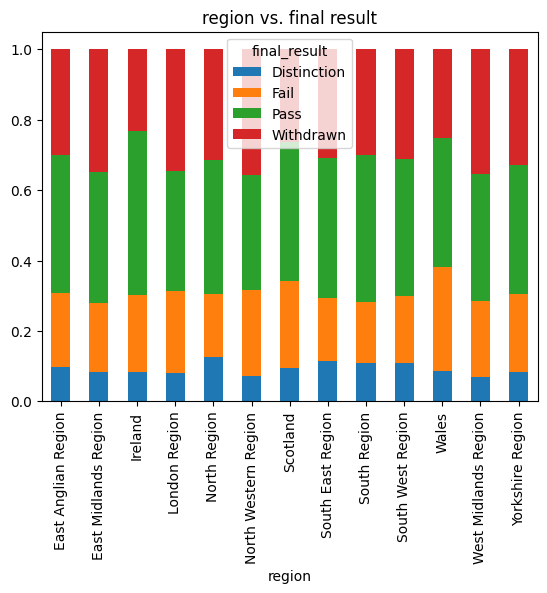

In [18]:
ct = pd.crosstab(df_studentInfo['region'], df_studentInfo['final_result'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title("region vs. final result")
plt.show()

In [19]:
ct = pd.crosstab(df_studentInfo['region'], df_studentInfo['final_result'])

chi2, p, dot, expected = chi2_contingency(ct)
print(f"Chi2: {chi2 : .2f}")
print(f"P-value: {p : .6f}")

Chi2:  449.72
P-value:  0.000000


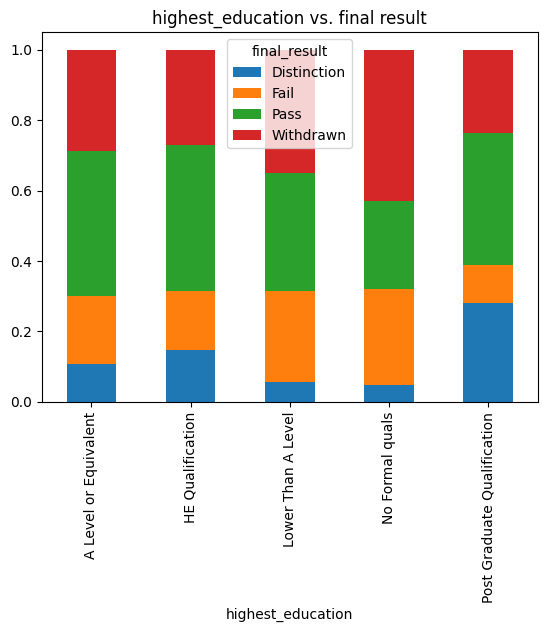

In [20]:
ct = pd.crosstab(df_studentInfo['highest_education'], df_studentInfo['final_result'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title("highest_education vs. final result")
plt.show()

In [21]:
ct = pd.crosstab(df_studentInfo['highest_education'], df_studentInfo['final_result'])

chi2, p, dot, expected = chi2_contingency(ct)
print(f"Chi2: {chi2 : .2f}")
print(f"P-value: {p : .6f}")

Chi2:  1024.70
P-value:  0.000000


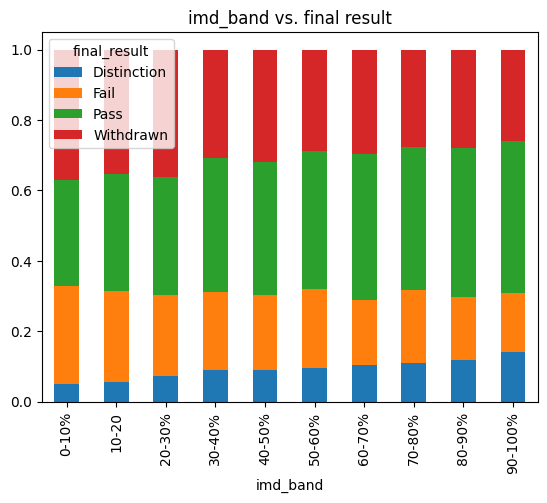

In [22]:
ct = pd.crosstab(df_studentInfo['imd_band'], df_studentInfo['final_result'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title("imd_band vs. final result")
plt.show()

In [23]:
ct = pd.crosstab(df_studentInfo['imd_band'], df_studentInfo['final_result'])

chi2, p, dot, expected = chi2_contingency(ct)
print(f"Chi2: {chi2 : .2f}")
print(f"P-value: {p : .6f}")

Chi2:  666.94
P-value:  0.000000


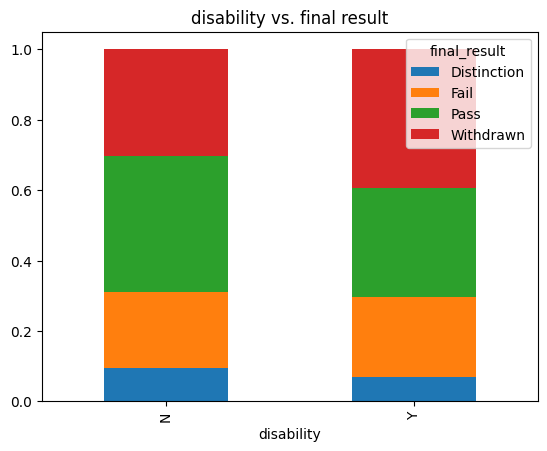

In [24]:
ct = pd.crosstab(df_studentInfo['disability'], df_studentInfo['final_result'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title("disability vs. final result")
plt.show()

In [25]:
ct = pd.crosstab(df_studentInfo['disability'], df_studentInfo['final_result'])

chi2, p, dot, expected = chi2_contingency(ct)
print(f"Chi2: {chi2 : .2f}")
print(f"P-value: {p : .6f}")

Chi2:  138.45
P-value:  0.000000


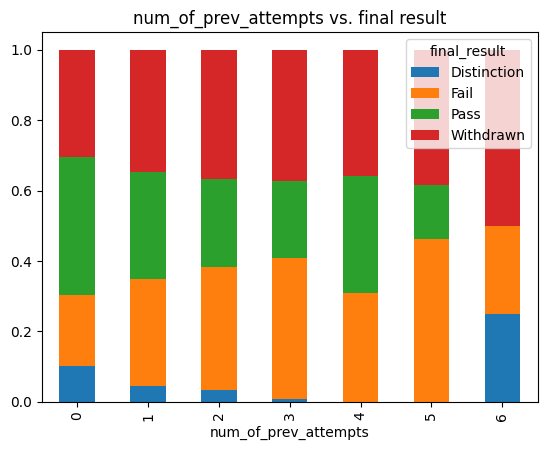

In [26]:
ct = pd.crosstab(df_studentInfo['num_of_prev_attempts'], df_studentInfo['final_result'], normalize='index')

ct.plot(kind='bar', stacked=True)
plt.title("num_of_prev_attempts vs. final result")
plt.show()

In [27]:
ct = pd.crosstab(df_studentInfo['num_of_prev_attempts'], df_studentInfo['final_result'])

chi2, p, dot, expected = chi2_contingency(ct)
print(f"Chi2: {chi2 : .2f}")
print(f"P-value: {p : .6f}")

Chi2:  515.53
P-value:  0.000000


In [28]:
for col in ['gender', 'highest_education', 'imd_band', 'disability']:
    ct = pd.crosstab(df_studentInfo[col], df_studentInfo['final_result'])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f'{col}: p-value = {p:.6f}')

gender: p-value = 0.000883
highest_education: p-value = 0.000000
imd_band: p-value = 0.000000
disability: p-value = 0.000000


Đa số tất cả các feature đều tương quan mạnh tới target, riêng gender là yếu nhất

In [29]:
df_merged = df_studentVle.merge(
    df_studentInfo[['id_student', 'final_result']],
    on = 'id_student',
    how='left'
)

df_merged.shape

(13006575, 7)

In [30]:
df_merged['week'] = df_merged['date']//7
weekly_clicks = df_merged.groupby(['week', 'final_result'])['sum_click'].sum().reset_index()

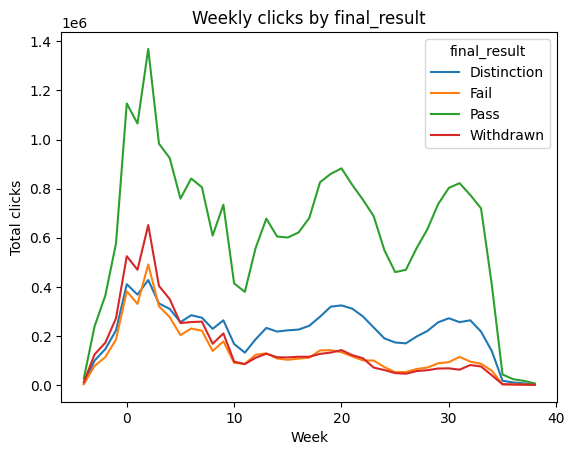

In [31]:
sns.lineplot(data=weekly_clicks, x='week', y='sum_click', hue='final_result')
plt.title('Weekly clicks by final_result')
plt.xlabel('Week')
plt.ylabel('Total clicks')
plt.show()

Số lượng click của nhóm withdrawn và fail càng về sau càng giảm mạnh và dần hướng về 0.

In [32]:
weekly_clicks_per_student = df_merged.groupby(['week', 'final_result'])['sum_click'].mean().reset_index()

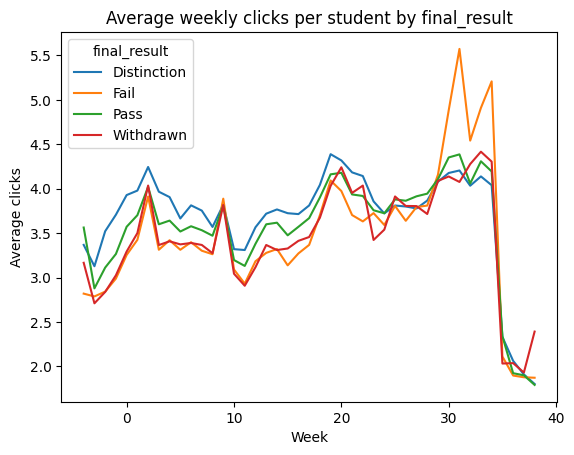

In [33]:
sns.lineplot(data=weekly_clicks_per_student, x='week', y='sum_click', hue='final_result')
plt.title('Average weekly clicks per student by final_result')
plt.xlabel('Week')
plt.ylabel('Average clicks')
plt.show()

Số lượng click các tuần đầu khá là tương đồng nhau. Số lượng click của Fail trên mỗi sinh viên càng về tuần sau càng tăng, dấu hiệu " nước đến chân mới nhảy". Số lượng của Withdrawn vẫn kéo nhịp và bám sát Distinction và Pass là do trung bình số lượng sinh viên về cuối mới bỏ kéo dần lên, có thể là họ đã click khá nhiều lần rồi mới quyết định bỏ học.

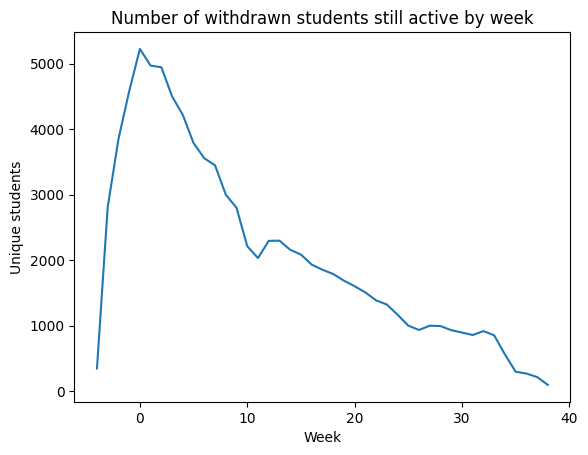

In [34]:
withdraw_by_week = df_merged[df_merged['final_result'] == 'Withdrawn'].groupby('week')['id_student'].nunique()

withdraw_by_week.plot()
plt.title('Number of withdrawn students still active by week')
plt.xlabel('Week')
plt.ylabel('Unique students')
plt.show()

In [35]:
active_by_week = df_merged.groupby(['week', 'final_result'])['id_student'].nunique().reset_index()
active_by_week.columns = ['week', 'final_result', 'active_students']

avg_clicks = df_merged.groupby(['week', 'final_result'])['sum_click'].mean().reset_index()
avg_clicks.columns = ['week', 'final_result', 'avg_clicks']

summary = avg_clicks.merge(active_by_week, on=['week', 'final_result'])
summary_late = df_merged[df_merged['week'] >= 30].groupby('final_result').agg(
    total_students=('id_student', 'nunique'),
    total_clicks=('sum_click', 'sum'),
    avg_clicks_per_student=('sum_click', 'mean')
).round(2)

print(summary_late)

              total_students  total_clicks  avg_clicks_per_student
final_result                                                      
Distinction             2860       1184944                    4.01
Fail                    2297        454870                    4.89
Pass                   11575       3617286                    4.16
Withdrawn               1295        335159                    4.14


Withdrawn tuần 30+: chỉ còn 1295 sinh viên (so với 10156 ban đầu) nhưng avg clicks = 4.14 — gần bằng Pass (4.16)
Fail avg clicks = 4.89 — cao nhất, đúng với insight "panic studying"
Vậy survivorship bias được chứng minh: 1295/10156 = chỉ ~13% Withdrawn còn "sống" đến tuần 30, và họ là những người chăm nhất trong nhóm đó

In [36]:
df_studentRegistration = pd.read_csv("/content/drive/MyDrive/Dataset/studentRegistration.csv")
df_studentRegistration.head(5)

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [37]:
df_assessments = pd.read_csv("/content/drive/MyDrive/Dataset/assessments.csv")
df_assessments.head(5)

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [38]:
df_courses = pd.read_csv("/content/drive/MyDrive/Dataset/courses.csv")
df_courses.head(5)

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [39]:
df_vle = pd.read_csv("/content/drive/MyDrive/Dataset/vle.csv")
df_vle.head(5)

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [40]:
early = df_studentVle[df_studentVle['date'] < 28]

early_clicks = early.groupby('id_student')['sum_click'].sum().reset_index()
early_clicks.columns = ['id_student', 'early_clicks']

In [41]:
early_clicks.head()

,id_student,early_clicks
0,6516,799
1,8462,350
2,11391,401
3,23629,53
4,23698,365


In [42]:
total_clicks = df_studentVle.groupby('id_student')['sum_click'].sum().reset_index()
total_clicks.columns = ['id_student', 'total_clicks']

click_std = df_studentVle.groupby('id_student')['sum_click'].std().reset_index()
click_std.columns = ['id_student', 'click_consistency']

active_days = df_studentVle.groupby('id_student')['date'].nunique().reset_index()
active_days.columns = ['id_student', 'active_days']

pre_course = df_studentVle[df_studentVle['date'] < 0]
pre_clicks = pre_course.groupby('id_student')['sum_click'].sum().reset_index()
pre_clicks.columns = ['id_student', 'pre_course_clicks']

In [43]:
df_features = df_studentInfo[['id_student', 'gender', 'age_band','highest_education', 'imd_band','disability', 'final_result']].copy()
df_features = df_features.merge(total_clicks, on='id_student', how='left')
df_features = df_features.merge(early_clicks, on='id_student', how='left')
df_features = df_features.merge(click_std, on='id_student', how='left')
df_features = df_features.merge(active_days, on='id_student', how='left')
df_features = df_features.merge(pre_clicks, on='id_student', how='left')

print(df_features.shape)
print(df_features.head())

(32593, 12)
   id_student gender age_band      highest_education imd_band disability  \
0       11391      M     55<=       HE Qualification  90-100%          N   
1       28400      F    35-55       HE Qualification   20-30%          N   
2       30268      F    35-55  A Level or Equivalent   30-40%          Y   
3       31604      F    35-55  A Level or Equivalent   50-60%          N   
4       32885      F     0-35     Lower Than A Level   50-60%          N   

  final_result  total_clicks  early_clicks  click_consistency  active_days  \
0         Pass         934.0         401.0           7.591224         40.0   
1         Pass        1435.0         550.0           3.634240         80.0   
2    Withdrawn         281.0         281.0           4.056336         12.0   
3         Pass        2158.0         478.0           3.194577        123.0   
4         Pass        1034.0         567.0           3.261895         70.0   

   pre_course_clicks  
0               98.0  
1              2

In [44]:
df_features.isnull().sum()

,0
id_student,0
gender,0
age_band,0
highest_education,0
imd_band,1111
disability,0
final_result,0
total_clicks,2852
early_clicks,3241
click_consistency,3027


In [45]:
df_features['has_clicks'] = (df_features['total_clicks'] > 0).astype(int)
for col in ['total_clicks', 'early_clicks', 'active_days', 'pre_course_clicks', 'click_consistency']:
  df_features[col] = df_features[col].fillna(0)

df_features['imd_band'] = df_features['imd_band'].fillna(df_features['imd_band'].mode()[0])

In [46]:
df_features.isnull().sum()

,0
id_student,0
gender,0
age_band,0
highest_education,0
imd_band,0
disability,0
final_result,0
total_clicks,0
early_clicks,0
click_consistency,0


In [47]:
df_assess_merged = df_studentAssessment.merge(
    df_assessments[['id_assessment', 'date', 'weight', 'assessment_type']],
    on = 'id_assessment',
    how = 'left'
)

df_assess_merged.head(5)

,id_assessment,id_student,date_submitted,is_banked,score,date,weight,assessment_type
0,1752,11391,18,0,78.0,19.0,10.0,TMA
1,1752,28400,22,0,70.0,19.0,10.0,TMA
2,1752,31604,17,0,72.0,19.0,10.0,TMA
3,1752,32885,26,0,69.0,19.0,10.0,TMA
4,1752,38053,19,0,79.0,19.0,10.0,TMA


In [48]:
df_assess_merged['days_before_deadline'] = df_assess_merged['date'] - df_assess_merged['date_submitted']
df_assess_merged['days_before_deadline'].describe()

,days_before_deadline
count,171047.000000
mean,16.657989
std,45.945880
min,-372.000000
25%,-2.000000
50%,1.000000
75%,6.000000
max,246.000000


In [49]:
assess_features = df_assess_merged.groupby('id_student').agg(
    avg_score=('score', 'mean'),
    avg_days_before_deadline=('days_before_deadline', 'mean'),
    num_assessments=('id_assessment', 'count')
).reset_index()

assess_features.head()

,id_student,avg_score,avg_days_before_deadline,num_assessments
0,6516,61.800000,2.600000,5
1,8462,87.000000,34.142857,7
2,11391,82.000000,1.800000,5
3,23629,82.500000,-3.500000,4
4,23698,74.444444,-1.125000,9


In [50]:
df_features = df_features.merge(assess_features, on='id_student', how='left')

df_features[['avg_score', 'avg_days_before_deadline', 'num_assessments']] = df_features[['avg_score', 'avg_days_before_deadline', 'num_assessments']].fillna(0)

print(df_features.shape)
print(df_features.columns.tolist())

(32593, 16)
['id_student', 'gender', 'age_band', 'highest_education', 'imd_band', 'disability', 'final_result', 'total_clicks', 'early_clicks', 'click_consistency', 'active_days', 'pre_course_clicks', 'has_clicks', 'avg_score', 'avg_days_before_deadline', 'num_assessments']


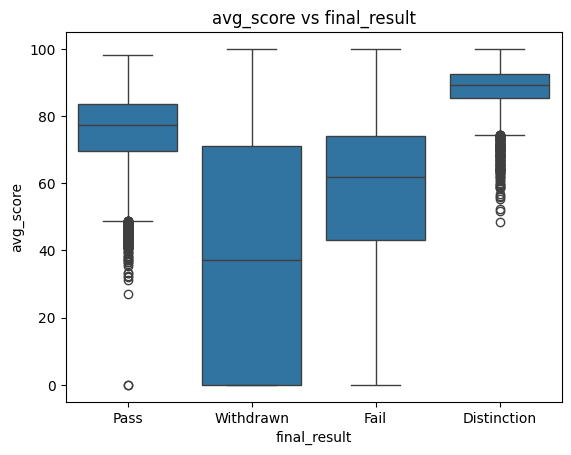

In [51]:
sns.boxplot(data=df_features, x='final_result', y='avg_score')
plt.title('avg_score vs final_result')
plt.show()

median của họ là ~35, rất thấp. Nhưng box rộng từ 0-70 nghĩa là có người điểm cao vẫn Withdrawn — họ bỏ học không phải vì học kém mà vì lý do khác (cá nhân, tài chính...).
Đây là lý do avg_score một mình không đủ để predict Withdrawn — cần kết hợp với click features.

In [52]:
cat_cols = ['gender', 'age_band', 'highest_education', 'imd_band', 'disability']

df_encoded = pd.get_dummies(df_features, columns=cat_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded.columns.tolist())

(32593, 28)
['id_student', 'final_result', 'total_clicks', 'early_clicks', 'click_consistency', 'active_days', 'pre_course_clicks', 'has_clicks', 'avg_score', 'avg_days_before_deadline', 'num_assessments', 'gender_M', 'age_band_35-55', 'age_band_55<=', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'disability_Y']


In [53]:
df_encoded.head(5)

,id_student,final_result,total_clicks,early_clicks,click_consistency,active_days,pre_course_clicks,has_clicks,avg_score,avg_days_before_deadline,...,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,disability_Y
0,11391,Pass,934.0,401.0,7.591224,40.0,98.0,1,82.0,1.8,...,False,False,False,False,False,False,False,False,True,False
1,28400,Pass,1435.0,550.0,3.634240,80.0,215.0,1,66.4,0.0,...,False,True,False,False,False,False,False,False,False,False
2,30268,Withdrawn,281.0,281.0,4.056336,12.0,102.0,1,0.0,0.0,...,False,False,True,False,False,False,False,False,False,True
3,31604,Pass,2158.0,478.0,3.194577,123.0,169.0,1,76.0,2.0,...,False,False,False,False,True,False,False,False,False,False
4,32885,Pass,1034.0,567.0,3.261895,70.0,295.0,1,54.4,-11.4,...,False,False,False,False,True,False,False,False,False,False


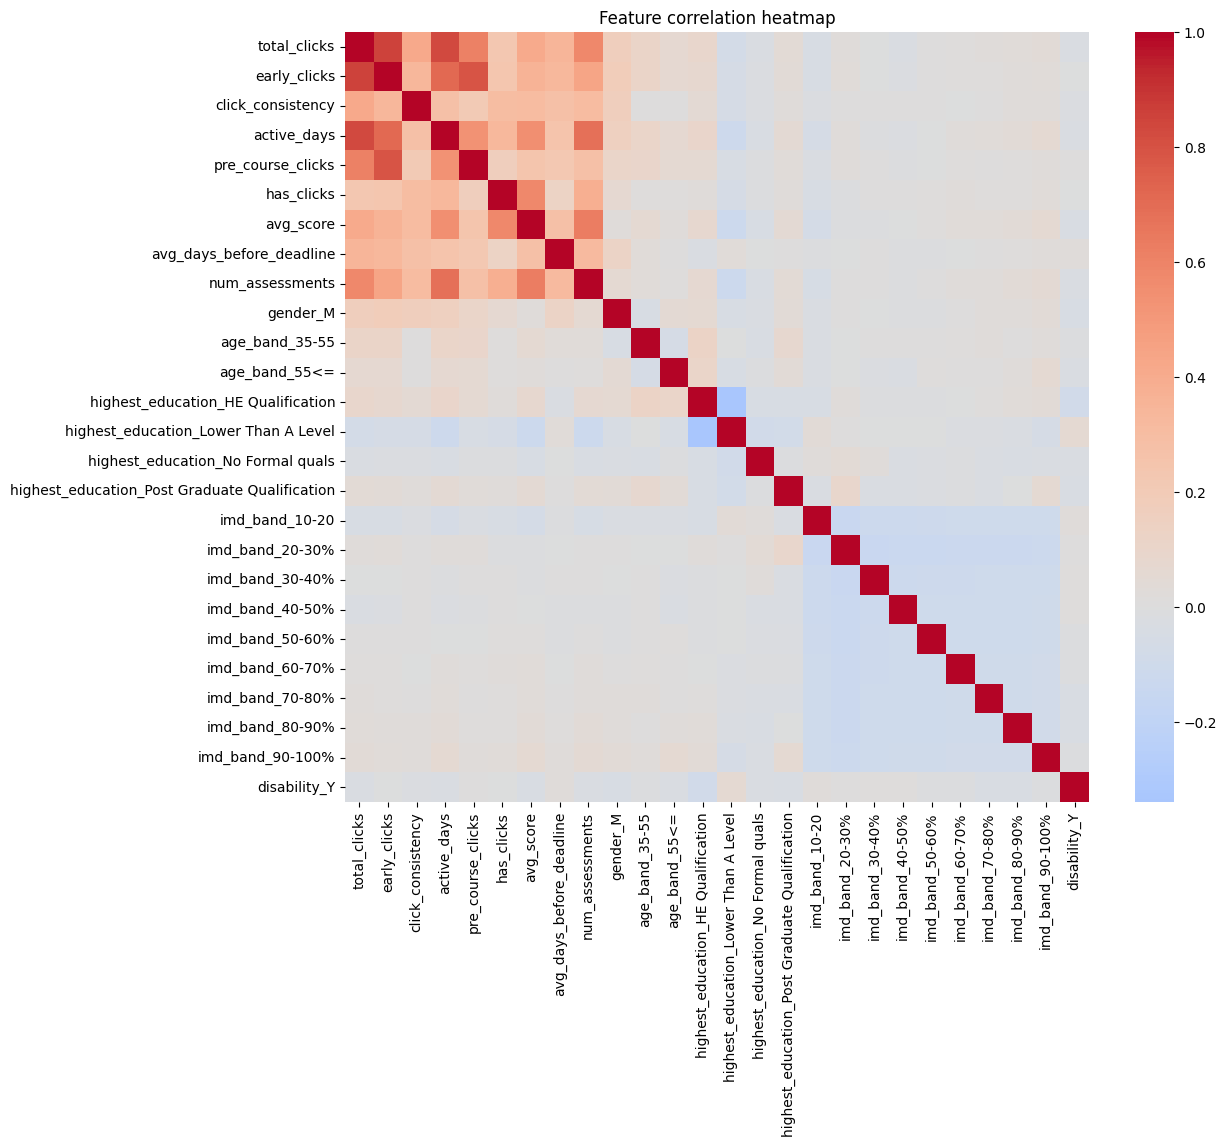

In [54]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.drop(columns=['id_student', 'final_result']).corr(),
            annot=False,
            cmap='coolwarm',
            center=0)

plt.title('Feature correlation heatmap')
plt.show()

In [55]:
df_encoded.to_csv('oulad_features.csv', index=False)

In [58]:
df_reg = df_studentRegistration.copy()

df_reg['unregistered'] = df_reg['date_unregistration'].notna().astype(int)

df_reg['days_to_unregister'] = df_reg['date_unregistration'].fillna(0)

reg_features = df_reg[['id_student', 'unregistered', 'days_to_unregister']]

df_encoded = df_encoded.merge(reg_features, on='id_student', how='left')
df_encoded[['unregistered', 'days_to_unregister']] = df_encoded[['unregistered', 'days_to_unregister']].fillna(0)

print(df_encoded.shape)

(102349, 34)


In [59]:
df_studentRegistration['id_student'].nunique()

28785

In [62]:
reg_features = df_studentRegistration.groupby('id_student').agg(
    unregistered=('date_unregistration', lambda x: x.notna().any().astype(int)),
    days_to_unregister=('date_unregistration', 'min')
).reset_index()

reg_features['days_to_unregister'] = reg_features['days_to_unregister'].fillna(0)

print(reg_features.shape)
print(reg_features.head())

(28785, 3)
   id_student  unregistered  days_to_unregister
0        3733             1                -8.0
1        6516             0                 0.0
2        8462             1                18.0
3       11391             0                 0.0
4       23629             0                 0.0


In [63]:
df_encoded = pd.read_csv('oulad_features.csv')
print(df_encoded.shape)

(32593, 28)


In [64]:
reg_features = df_studentRegistration.groupby('id_student').agg(
    unregistered=('date_unregistration', lambda x: x.notna().any().astype(int)),
    days_to_unregister=('date_unregistration', 'min')
).reset_index()

reg_features['days_to_unregister'] = reg_features['days_to_unregister'].fillna(0)

print(reg_features.shape)
print(reg_features.head())

(28785, 3)
   id_student  unregistered  days_to_unregister
0        3733             1                -8.0
1        6516             0                 0.0
2        8462             1                18.0
3       11391             0                 0.0
4       23629             0                 0.0


In [71]:
for col_name in ['unregistered', 'days_to_unregister']:
    if col_name in df_encoded.columns:
        df_encoded = df_encoded.drop(columns=[col_name])
    if f'{col_name}_x' in df_encoded.columns:
        df_encoded = df_encoded.drop(columns=[f'{col_name}_x'])

df_encoded = df_encoded.merge(reg_features, on='id_student', how='left')
df_encoded[['unregistered', 'days_to_unregister']] = df_encoded[['unregistered', 'days_to_unregister']].fillna(0)

print(df_encoded.shape)

(32593, 32)


In [72]:
print(df_encoded.columns.tolist())

['id_student', 'final_result', 'total_clicks', 'early_clicks', 'click_consistency', 'active_days', 'pre_course_clicks', 'has_clicks', 'avg_score', 'avg_days_before_deadline', 'num_assessments', 'gender_M', 'age_band_35-55', 'age_band_55<=', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'disability_Y', 'unregistered_y', 'days_to_unregister_y', 'unregistered', 'days_to_unregister']


In [73]:
df_encoded = df_encoded.drop(columns=['unregistered_y', 'days_to_unregister_y'])
print(df_encoded.shape)

(32593, 30)


In [74]:
df_vle_merged = df_studentVle.merge(
    df_vle[['id_site', 'activity_type']],
    on='id_site',
    how='left'
)

vle_activity = df_vle_merged.groupby(
    ['id_student', 'activity_type']
)['sum_click'].sum().unstack(fill_value=0).reset_index()

print(vle_activity.shape)
print(vle_activity.head())

(26074, 21)
activity_type  id_student  dataplus  dualpane  externalquiz  folder  forumng  \
0                    6516        21         0             0       0      451   
1                    8462         0         0            12       0       38   
2                   11391         0         0             0       0      193   
3                   23629         0         0             0       0       87   
4                   23698         0         0             0       0       63   

activity_type  glossary  homepage  htmlactivity  oucollaborate  ...  \
0                     0       497             0              0  ...   
1                     0       191             0             13  ...   
2                     0       138             0              0  ...   
3                     0        36             0              0  ...   
4                     0       121             0              0  ...   

activity_type  ouelluminate  ouwiki  page  questionnaire  quiz  \
0             

In [75]:
df_encoded = df_encoded.merge(vle_activity, on='id_student', how='left')
df_encoded = df_encoded.fillna(0)

print(df_encoded.shape)

(32593, 50)


In [76]:
df_encoded.to_csv('oulad_features_final.csv', index=False)

In [77]:
df_encoded['at_risk'] = df_encoded['final_result'].apply(
    lambda x: 1 if x in ['Withdrawn', 'Fail'] else 0
)

In [78]:
df_encoded['at_risk'].value_counts()

,count
at_risk,
1,17208
0,15385
